# LevETF vs Total Return â€” LVC (Amundi 2Ã— CAC) vs CAC 40 TR

**Objective:** Quantify exactly how much the daily-rebalancing mechanism costs LVC holders relative to a hypothetical unleveraged or margin-leveraged position in the CAC 40 Total Return index.

**Key questions:**
- How far does LVC trail a theoretical 2Ã— CAC TR?
- How much of the gap is volatility decay vs TER drag?
- When did the gap widen most (crisis periods)?
- Would a 2Ã— CAC TR margin account have been materially better?

In [9]:
import sys
import importlib
import pandas as pd
import numpy as np
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display
import warnings; warnings.filterwarnings('ignore')

# â”€â”€ Signum charting â”€â”€
sys.path.insert(0, r"C:\Personal\Business & Investments\Python codes")
# Force-reload signum so any edits to chart.py / dashboard.py take effect
import signum.engine.chart as _sc; importlib.reload(_sc)
import signum.engine.dashboard as _sd; importlib.reload(_sd)
import signum.engine as _se; importlib.reload(_se)
import signum as _sig; importlib.reload(_sig)
from signum import Chart, Dashboard

# â”€â”€ Sfera DB â”€â”€
import sfera_db

# â”€â”€ Load CAC price return â”€â”€
cac_px   = sfera_db.index_prices('CAC')[['close']]
cac_ivol = sfera_db.index_ivol('CAC')[['ivol']]
cac_tr_raw = sfera_db.read_table('index_total_return', ticker='CACT')[['close_price']]
cac_tr_px  = cac_tr_raw.rename(columns={'close_price': 'close'})

# Align CAC series
common_cac = cac_px.index.intersection(cac_ivol.index).intersection(cac_tr_px.index)
cac = pd.DataFrame({
    'close':    cac_px.loc[common_cac, 'close'],
    'close_tr': cac_tr_px.loc[common_cac, 'close'],
    'ivol':     cac_ivol.loc[common_cac, 'ivol'],
}).sort_index()
cac['ret_pr'] = cac['close'].pct_change()
cac['ret_tr'] = cac['close_tr'].pct_change()
cac = cac.dropna(subset=['ret_pr', 'ret_tr'])

# â”€â”€ Load LVC (2Ã— CAC, Amundi) â”€â”€
LVC_CSV = Path(r"C:\Personal\Business & Investments\Trading portfolio\Strategies\ETF TKAN\Data\lvc_ohlcv.csv")
lvc_raw = pd.read_csv(LVC_CSV, parse_dates=['date'], index_col='date').sort_index()

# â”€â”€ Align to common LVC window â”€â”€
common = cac.index.intersection(lvc_raw.index)
df = pd.DataFrame({
    'lvc':    lvc_raw.loc[common, 'close'],
    'cac_pr': cac.loc[common, 'close'],
    'cac_tr': cac.loc[common, 'close_tr'],
    'ivol':   cac.loc[common, 'ivol'],
}).dropna()
df['lvc_ret']    = df['lvc'].pct_change()
df['cac_pr_ret'] = df['cac_pr'].pct_change()
df['cac_tr_ret'] = df['cac_tr'].pct_change()
df = df.dropna()

# â”€â”€ Load EUR overnight rate (EONIA â†’ â‚¬STR splice) â”€â”€
_RATES_CSV = Path(r"C:\Personal\Business & Investments\Trading portfolio\ForgeFolio\data\eur_overnight_rate.csv")
_rates = (
    pd.read_csv(_RATES_CSV, parse_dates=['date'], index_col='date')
    ['rate_pct']
    .reindex(df.index, method='ffill')  # fill calendar gaps with last known rate
)
# â”€â”€ Margin strategy parameters â”€â”€
# Structure: deploy 100% equity into CAC TR, then borrow another 100% of equity
# to buy more CAC TR â†’ total position = 2Ã— equity (matching LVC exposure).
# The loan = 1Ã— equity, so financing cost = borrow_rate Ã— 1.0 (not Ã— 0.5).
#
# IBKR Pro EUR spread (balance < â‚¬90 K tier):
IBKR_SPREAD = 0.015          # +1.50 % over â‚¬STR
#   Full borrow rate  = â‚¬STR/100 + IBKR_SPREAD  (annual, fractional)
#   Daily borrow cost = full_borrow_rate / 252   (applied to 1Ã— equity loan)
#
# Daily P&L on equity:
#   margin_ret = 2 Ã— cac_tr_ret          â† gain on 2Ã— exposure
#              - borrow_daily             â† interest on the 1Ã— loan
df['overnight_pct'] = _rates                                    # annualised %, e.g. 1.934
df['borrow_daily']  = (_rates / 100 + IBKR_SPREAD) / 252       # daily cost on 1Ã— equity loan
df['margin_ret']    = 2 * df['cac_tr_ret'] - df['borrow_daily'] # return on equity
df = df.dropna(subset=['margin_ret'])

print(f"Date range  : {df.index[0].date()} â†’ {df.index[-1].date()}  ({len(df)} days)")
print(f"IBKR borrow : â‚¬STR + {IBKR_SPREAD*100:.2f}%  "
      f"current = {(_rates.iloc[-1]/100 + IBKR_SPREAD)*100:.2f}%/yr  "
      f"daily drag = {df['borrow_daily'].iloc[-1]*100:.4f}%")
print(f"Strategy    : 100% equity in CAC TR  +  100% borrowed â†’ 2Ã— total exposure")


Date range  : 2008-05-26 â†’ 2026-03-20  (4559 days)
IBKR borrow : â‚¬STR + 1.50%  current = 3.43%/yr  daily drag = 0.0136%
Strategy    : 100% equity in CAC TR  +  100% borrowed â†’ 2Ã— total exposure


## 1 â€” Base-100 Equity Curves: LVC vs CAC PR vs CAC TR

In [10]:

# â”€â”€ Cumulative equity curves (base 100) â”€â”€
t = df.index

# Helper: wrap a series as a DataFrame for Chart.line().
# NaN values are kept as-is â€” Signum emits LWC whitespace records for NaN so
# the full time axis stays anchored and panes remain time-aligned.
def _dl(index, values):
    s = pd.Series(values, index=index)
    return pd.DataFrame({'time': s.index, 'value': s.values})

def _norm(s): return s / s.iloc[0] * 100

eq_lvc    = _norm(df['lvc'])
eq_cac_pr = _norm(df['cac_pr'])
eq_cac_tr = _norm(df['cac_tr'])
eq_margin = _norm((1 + df['margin_ret']).cumprod())   # synthetic 2Ã— CAC TR on IBKR margin

def _stats(ret, label):
    eq = (1 + ret).cumprod()
    sh = ret.mean() / ret.std() * np.sqrt(252)
    mdd = ((eq - eq.cummax()) / eq.cummax()).min() * 100
    n_yr = len(ret) / 252
    cagr = (eq.iloc[-1]) ** (1 / n_yr) - 1
    print(f"{label:14s}  Total {(eq.iloc[-1]-1)*100:+7.1f}%  CAGR {cagr*100:+5.1f}%/yr  "
          f"Sharpe {sh:.3f}  MaxDD {mdd:.1f}%")

_stats(df['lvc_ret'],    'LVC 2Ã—')
_stats(df['margin_ret'], '2Ã— margin')
_stats(df['cac_tr_ret'], 'CAC TR (1Ã—)')
_stats(df['cac_pr_ret'], 'CAC PR (1Ã—)')

# â”€â”€ Rolling Sharpe (252d) â€” first 251 days are NaN â†’ rendered as gap â”€â”€
_W = 252
def _sharpe(r): return r.mean() / r.std() * np.sqrt(252)
sh_lvc    = df['lvc_ret'].rolling(_W).apply(_sharpe, raw=True)
sh_margin = df['margin_ret'].rolling(_W).apply(_sharpe, raw=True)
sh_tr     = df['cac_tr_ret'].rolling(_W).apply(_sharpe, raw=True)

# â”€â”€ Drawdowns â”€â”€
def _drawdown(ret):
    eq = (1 + ret).cumprod()
    return (eq - eq.cummax()) / eq.cummax() * 100

dd_lvc    = _drawdown(df['lvc_ret'])
dd_margin = _drawdown(df['margin_ret'])
dd_tr     = _drawdown(df['cac_tr_ret'])
dd_pr     = _drawdown(df['cac_pr_ret'])

# â”€â”€ Days underwater (calendar days since last all-time high) â”€â”€
# Shows the LENGTH of each drawdown episode on the same time axis as depth.
def _days_underwater(ret):
    eq  = (1 + ret).cumprod()
    ath = eq.cummax()
    in_dd = eq < ath
    days = pd.Series(0.0, index=ret.index)
    counter = 0
    for i, (d, v) in enumerate(in_dd.items()):
        if v:
            counter += 1
        else:
            counter = 0
        days.iloc[i] = counter
    return days

duw_lvc    = _days_underwater(df['lvc_ret'])
duw_margin = _days_underwater(df['margin_ret'])
duw_tr     = _days_underwater(df['cac_tr_ret'])
duw_pr     = _days_underwater(df['cac_pr_ret'])

# â”€â”€ Borrow rate (â‚¬STR + IBKR spread) â”€â”€
total_borrow_rate = (df['overnight_pct'] / 100 + IBKR_SPREAD) * 100  # annualised %

# â”€â”€ Combined time-aligned Dashboard â”€â”€
p_eq = (
    Chart(height=300, theme='distfit')
    .line(_dl(t, eq_lvc),    name='LVC 2Ã—',      color='#a78bfa', width=2)
    .line(_dl(t, eq_margin), name='2Ã— margin',   color='#f59e0b', width=2)
    .line(_dl(t, eq_cac_tr), name='CAC TR (1Ã—)', color='#34d399', width=2)
    .line(_dl(t, eq_cac_pr), name='CAC PR (1Ã—)', color='#60a5fa', width=1)
)

p_sh = (
    Chart(height=180, theme='distfit')
    .line(_dl(t, sh_lvc),    name='LVC Sharpe',       color='#a78bfa', width=1)
    .line(_dl(t, sh_margin), name='2Ã— margin Sharpe', color='#f59e0b', width=1)
    .line(_dl(t, sh_tr),     name='CAC TR Sharpe',    color='#34d399', width=1)
)

p_dd = (
    Chart(height=180, theme='distfit')
    .line(_dl(t, dd_lvc),    name='LVC 2Ã—',      color='#a78bfa', width=1)
    .line(_dl(t, dd_margin), name='2Ã— margin',   color='#f59e0b', width=1)
    .line(_dl(t, dd_tr),     name='CAC TR (1Ã—)', color='#34d399', width=1)
    .line(_dl(t, dd_pr),     name='CAC PR (1Ã—)', color='#60a5fa', width=1)
)

p_duw = (
    Chart(height=140, theme='distfit')
    .line(_dl(t, duw_lvc),    name='LVC 2Ã—',      color='#a78bfa', width=1)
    .line(_dl(t, duw_margin), name='2Ã— margin',   color='#f59e0b', width=1)
    .line(_dl(t, duw_tr),     name='CAC TR (1Ã—)', color='#34d399', width=1)
    .line(_dl(t, duw_pr),     name='CAC PR (1Ã—)', color='#60a5fa', width=1)
)

p_rate = (
    Chart(height=120, theme='distfit')
    .line(_dl(t, df['overnight_pct']),  name='â‚¬STR / EONIA (%/yr)',                color='#94a3b8', width=1)
    .line(_dl(t, total_borrow_rate),    name='Total borrow rate â‚¬STR+1.5% (%/yr)', color='#fb923c', width=1)
)

Dashboard(
    panes=[p_eq, p_sh, p_dd, p_duw, p_rate],
    titles=[
        'LVC 2Ã— / 2Ã— margin (IBKR) / CAC TR (1Ã—) / CAC PR (1Ã—) â€” base-100',
        f'Rolling {_W}d Sharpe  (first {_W-1} days = warm-up gap)',
        'Drawdown (%)',
        'Days Underwater (trading days since last ATH)',
        'EUR Overnight Borrow Rate (%/yr)  â€”  â‚¬STR/EONIA  +  IBKR spread',
    ],
    theme='distfit',
)


LVC 2Ã—          Total   +95.6%  CAGR  +3.8%/yr  Sharpe 0.299  MaxDD -78.2%
2Ã— margin       Total  +131.9%  CAGR  +4.8%/yr  Sharpe 0.324  MaxDD -78.7%
CAC TR (1Ã—)     Total  +181.0%  CAGR  +5.9%/yr  Sharpe 0.374  MaxDD -49.1%
CAC PR (1Ã—)     Total   +55.4%  CAGR  +2.5%/yr  Sharpe 0.221  MaxDD -49.8%


## 2 â€” Year-by-Year Returns & Volatility

In [11]:
def _ann_ret(s): return (1 + s).resample('YE').prod() - 1
def _ann_vol(s): return s.resample('YE').std() * np.sqrt(252) * 100

ar_pr      = _ann_ret(df['cac_pr_ret'])  * 100
ar_tr      = _ann_ret(df['cac_tr_ret'])  * 100
ar_lvc     = _ann_ret(df['lvc_ret'])     * 100
ar_margin  = _ann_ret(df['margin_ret'])  * 100
ar_borrow  = df['borrow_daily'].resample('YE').sum() * 100  # actual annual financing drag (%)
yrs        = ar_pr.index.year

ytbl = pd.DataFrame({
    'CAC PR %':       ar_pr.values,
    'CAC TR %':       ar_tr.values,
    'LVC %':          ar_lvc.values,
    '2Ã— Margin %':    ar_margin.values,
    'Borrow Cost %':  ar_borrow.values,
    'Î” LVCâˆ’TR %':     (ar_lvc - ar_tr).values,
    'Î” Mgnâˆ’TR %':     (ar_margin - ar_tr).values,
    'Vol LVC %':      _ann_vol(df['lvc_ret']).values,
    'Vol Mgn %':      _ann_vol(df['margin_ret']).values,
}, index=yrs).round(2)

ytbl.loc['Full period'] = [
    round(((1 + df['cac_pr_ret']).prod()  - 1) * 100, 2),
    round(((1 + df['cac_tr_ret']).prod()  - 1) * 100, 2),
    round(((1 + df['lvc_ret']).prod()     - 1) * 100, 2),
    round(((1 + df['margin_ret']).prod()  - 1) * 100, 2),
    round(df['borrow_daily'].mean() * 252 * 100, 2),  # avg annualised borrow rate
    round(((1 + df['lvc_ret']).prod() - 1) * 100  - ((1 + df['cac_tr_ret']).prod() - 1) * 100, 2),
    round(((1 + df['margin_ret']).prod() - 1) * 100 - ((1 + df['cac_tr_ret']).prod() - 1) * 100, 2),
    round(df['lvc_ret'].std()    * np.sqrt(252) * 100, 2),
    round(df['margin_ret'].std() * np.sqrt(252) * 100, 2),
]
ytbl.loc['Mean'] = ytbl.loc[yrs].mean().round(2)

ret_cols = ['CAC PR %', 'CAC TR %', 'LVC %', '2Ã— Margin %']
cst_cols = ['Borrow Cost %']
dlt_cols = ['Î” LVCâˆ’TR %', 'Î” Mgnâˆ’TR %']
vol_cols = ['Vol LVC %', 'Vol Mgn %']

display(
    ytbl.style
    .background_gradient(subset=pd.IndexSlice[yrs, ret_cols], cmap='RdYlGn', vmin=-50, vmax=60, axis=None)
    .background_gradient(subset=pd.IndexSlice[yrs, cst_cols], cmap='RdYlGn_r', vmin=0, vmax=6, axis=None)
    .background_gradient(subset=pd.IndexSlice[yrs, dlt_cols], cmap='RdYlGn', vmin=-30, vmax=30, axis=None)
    .background_gradient(subset=pd.IndexSlice[yrs, vol_cols], cmap='RdYlGn_r', vmin=10, vmax=60, axis=None)
    .format({c: '{:+.2f}' for c in ret_cols + dlt_cols}
           | {c: '{:.2f}' for c in vol_cols}
           | {'Borrow Cost %': '{:.2f}'})
    .set_caption(
        'Year-by-year returns â€” Borrow Cost %: actual annual financing drag on 1Ã— loan  |  '
        'Î” LVCâˆ’TR: LevETF drag  |  Î” Mgnâˆ’TR: net leverage gain after financing'
    )
)

,CAC PR %,CAC TR %,LVC %,2Ã— Margin %,Borrow Cost %,Î” LVCâˆ’TR %,Î” Mgnâˆ’TR %,Vol LVC %,Vol Mgn %
2008,-34.78,-33.42,-64.11,-62.61,3.26,-30.69,-29.18,93.28,94.52
2009,+22.32,+27.58,+36.70,+48.20,2.24,+9.12,+20.62,51.62,53.10
2010,-2.17,+1.77,-11.10,-3.87,1.97,-12.87,-5.64,40.37,46.95
2011,-17.94,-14.42,-34.77,-34.19,2.42,-20.35,-19.76,55.71,56.76
2012,+14.57,+19.68,+34.86,+34.84,1.74,+15.18,+15.16,40.32,41.55
2013,+18.66,+22.92,+44.89,+44.79,1.61,+21.97,+21.87,31.50,32.40
2014,-0.54,+2.71,+0.70,+1.11,1.61,-2.00,-1.60,31.54,32.24
2015,+9.46,+12.91,+20.79,+19.48,1.41,+7.88,+6.57,43.96,44.77
2016,+3.96,+7.95,+9.91,+9.95,1.20,+1.96,+2.00,41.58,42.01
2017,+9.26,+12.73,+24.62,+24.24,1.16,+11.90,+11.51,20.69,20.97


## 3 â€” Leverage Premium Decomposition

### 2Ã— Margin strategy â€” how it is modelled

| | |
|---|---|
| **Capital** | 100% equity deployed into CAC 40 TR |
| **Loan** | Borrow 100% of equity at IBKR Pro EUR rate (â‚¬STR + 1.50%) |
| **Total exposure** | 200% of equity â€” identical gross leverage to LVC |
| **Daily return on equity** | $r^\text{margin}_t = 2\,r^\text{CAC TR}_t - \dfrac{\text{â‚¬STR} + 1.50\%}{252}$ |

This is **path-independent** â€” no daily reset, no volatility decay. The only drag is the financing cost on the loan.

---

### LVC drag decomposition

LVC's daily shortfall vs a perfect 2Ã— replication:

$$\text{premium}_t = r^\text{LVC}_t - 2 \cdot r^\text{CAC TR}_t$$

This is **negative on average** due to three compounding costs:
1. **Volatility decay** â€” daily reset locks in convexity losses: $\approx -\sigma^2$ per year
2. **TER** â€” Amundi LVC charges ~0.60%/yr
3. **Embedded swap/financing cost** inside the fund's total-return swap

The rolling 1-year average of this premium vs the margin premium shows the live cost difference.

In [12]:
# â”€â”€ Daily leverage premium: LVC âˆ’ 2Ã—CAC TR â”€â”€
df['lev_prem']  = df['lvc_ret'] - 2 * df['cac_tr_ret']
# Margin premium: how much the synthetic 2Ã— margin position adds over 1Ã— CAC TR
df['mgn_prem']  = df['margin_ret'] - df['cac_tr_ret']   # net leverage gain after financing

# Theoretical volatility drag: -ÏƒÂ² Ã— (LÂ²âˆ’L)/2  (L=2 â†’ -ÏƒÂ²)
roll_252 = df['cac_tr_ret'].rolling(252)
df['vol_drag_theory'] = -roll_252.var() * 252  # annualised

# Annualised rolling premiums
df['lev_prem_roll'] = df['lev_prem'].rolling(252).mean() * 252
df['mgn_prem_roll'] = df['mgn_prem'].rolling(252).mean() * 252

# â”€â”€ Summary stats â”€â”€
lp = df['lev_prem']
ann_prem  = lp.mean() * 252 * 100
ann_vol   = lp.std()  * np.sqrt(252) * 100
cac_var   = df['cac_tr_ret'].var() * 252
vol_decay = -cac_var * 100
residual  = ann_prem - vol_decay          # TER + swap cost
ann_mgn_prem = df['mgn_prem'].mean() * 252 * 100

print(f"â”€â”€ LVC vs 2Ã—CAC TR â”€â”€")
print(f"  Annualised leverage premium (LVC âˆ’ 2Ã—TR): {ann_prem:+.2f}%/yr")
print(f"  Theoretical vol decay  (âˆ’ÏƒÂ²_TR Ã— 252):   {vol_decay:+.2f}%/yr")
print(f"  Residual (TER + swap):                    {residual:+.2f}%/yr")
print(f"  Vol of premium:                           {ann_vol:.2f}%/yr")
print()
print(f"â”€â”€ 2Ã— Margin vs 1Ã—CAC TR â”€â”€")
print(f"  Annualised margin premium (Margin âˆ’ TR):  {ann_mgn_prem:+.2f}%/yr")
print(f"  (= leverage gain offset by IBKR borrow cost)")
print()
print(f"â”€â”€ LVC vs 2Ã— Margin  (LevETF cost relative to margin strategy) â”€â”€")
print(f"  LVC drag vs margin: {ann_prem - ann_mgn_prem:+.2f}%/yr  "
      f"(negative â†’ margin wins by this amount)")

t = df.index
p_prem = (
    Chart(height=280)
    .line(pd.DataFrame({'time': t, 'value': (df['lev_prem_roll'] * 100).values}),
          name='LVC premium vs 2Ã—TR', color='#f87171', width=2)
    .line(pd.DataFrame({'time': t, 'value': (df['mgn_prem_roll'] * 100).values}),
          name='Margin premium vs 1Ã—TR', color='#f59e0b', width=2)
)

p_ivol2 = (
    Chart(height=160)
    .line(pd.DataFrame({'time': t, 'value': df['ivol'].values}), name='IVol', color='#fb923c', width=1)
)

Dashboard(
    panes=[p_prem, p_ivol2],
    titles=[
        'Rolling 252-day annualised premiums (%/yr)  â€”  âš ï¸ LVC drag worsens in high-IVol',
        'CAC IVol',
    ],
    theme='distfit',
)

â”€â”€ LVC vs 2Ã—CAC TR â”€â”€
  Annualised leverage premium (LVC âˆ’ 2Ã—TR): -3.48%/yr
  Theoretical vol decay  (âˆ’ÏƒÂ²_TR Ã— 252):   -4.58%/yr
  Residual (TER + swap):                    +1.11%/yr
  Vol of premium:                           26.34%/yr

â”€â”€ 2Ã— Margin vs 1Ã—CAC TR â”€â”€
  Annualised margin premium (Margin âˆ’ TR):  +5.85%/yr
  (= leverage gain offset by IBKR borrow cost)

â”€â”€ LVC vs 2Ã— Margin  (LevETF cost relative to margin strategy) â”€â”€
  LVC drag vs margin: -9.33%/yr  (negative â†’ margin wins by this amount)


## 4 â€” Rolling Sharpe & Volatility (adjustable window)

In [13]:

# Rolling Sharpe widget â€” adjustable window (standalone, for deeper exploration)
sl_win = widgets.IntSlider(
    value=252, min=60, max=504, step=21,
    description='Window (days)', continuous_update=False,
    style={'description_width': '130px'}, layout=widgets.Layout(width='60%')
)
out_roll = widgets.Output()

def _draw_rolling(w):
    t = df.index
    def _sh(r): return r.mean() / r.std() * np.sqrt(252)
    def _vol(r): return r.std() * np.sqrt(252) * 100
    def _dl(idx, vals):
        # Keep NaN â€” Signum converts to JSON null so LightweightCharts shows a
        # gap while the full time axis stays aligned.
        s = pd.Series(vals, index=idx)
        return pd.DataFrame({'time': s.index, 'value': s.values})
    roll = df[['lvc_ret', 'cac_tr_ret', 'margin_ret']].rolling(w)
    sh_lvc    = roll['lvc_ret'].apply(_sh, raw=True)
    sh_margin = roll['margin_ret'].apply(_sh, raw=True)
    sh_tr     = roll['cac_tr_ret'].apply(_sh, raw=True)
    vol_lvc    = _vol(roll['lvc_ret'])
    vol_margin = _vol(roll['margin_ret'])
    vol_tr     = _vol(roll['cac_tr_ret'])
    p_sh = (
        Chart(height=220, theme='distfit')
        .line(_dl(t, sh_lvc),    name='LVC Sharpe',       color='#a78bfa', width=1)
        .line(_dl(t, sh_margin), name='2Ã— margin Sharpe', color='#f59e0b', width=1)
        .line(_dl(t, sh_tr),     name='CAC TR Sharpe',    color='#34d399', width=1)
    )
    p_vol = (
        Chart(height=180, theme='distfit')
        .line(_dl(t, vol_lvc),    name='LVC Vol %',       color='#a78bfa', width=1)
        .line(_dl(t, vol_margin), name='2Ã— margin Vol %', color='#f59e0b', width=1)
        .line(_dl(t, vol_tr),     name='CAC TR Vol %',    color='#34d399', width=1)
    )
    return Dashboard(
        panes=[p_sh, p_vol],
        titles=[f'Rolling {w}d Sharpe  (first {w-1} days = warm-up gap)', f'Rolling {w}d Vol (%)'],
        theme='distfit',
    )

def _on_win(change):
    with out_roll:
        from IPython.display import clear_output
        clear_output(wait=True)
        display(_draw_rolling(change['new']))

sl_win.observe(_on_win, names='value')
with out_roll:
    display(_draw_rolling(sl_win.value))
display(widgets.VBox([sl_win, out_roll]))


## 6 â€” Return Distribution: Skew, Kurtosis & Tail Risk

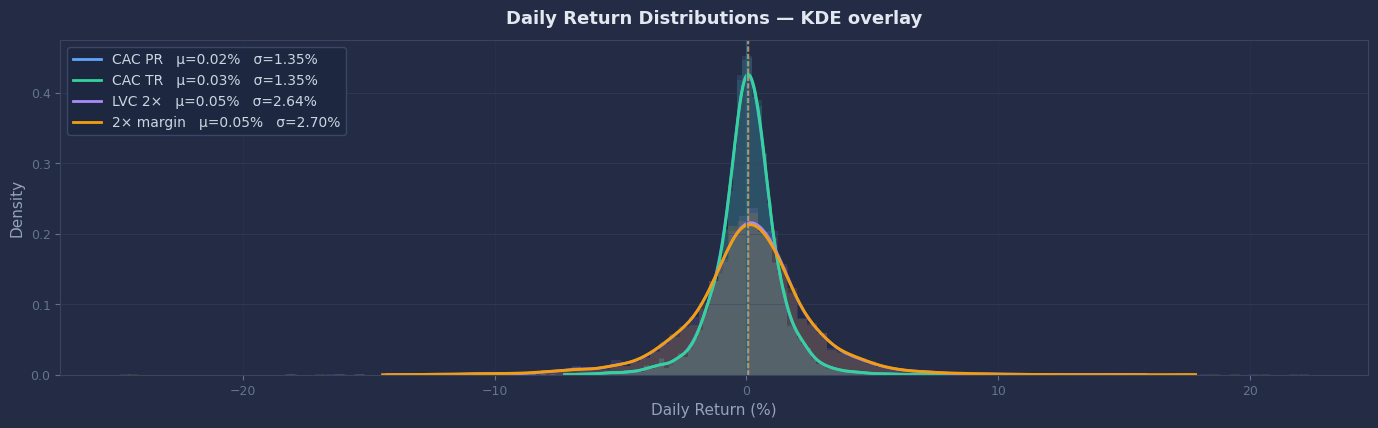

,Mean (bps/d),Std (bps/d),Skewness,Ex. Kurtosis,p1%,p5%,p95%,p99%
Series,,,,,,,,
CAC PR,1.900000,134.900000,-0.061,8.63,-3.95,-2.04,1.98,3.45
CAC TR,3.200000,134.900000,-0.058,8.70,-3.94,-2.03,1.99,3.52
LVC 2Ã—,5.000000,263.800000,-0.182,8.45,-7.58,-4.01,3.89,6.83
2Ã— margin,5.500000,269.700000,-0.059,8.69,-7.89,-4.06,3.97,7.04


In [14]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

series = {
    'CAC PR':    df['cac_pr_ret'],
    'CAC TR':    df['cac_tr_ret'],
    'LVC 2Ã—':    df['lvc_ret'],
    '2Ã— margin': df['margin_ret'],
}
colors = {'CAC PR': '#60a5fa', 'CAC TR': '#34d399', 'LVC 2Ã—': '#a78bfa', '2Ã— margin': '#f59e0b'}

_BG  = '#232b45'
_SUB = '#3a4460'

fig, ax = plt.subplots(figsize=(14, 4.5), facecolor=_BG)
ax.set_facecolor(_BG)

for label, ret in series.items():
    x = ret.dropna() * 100
    c = colors[label]
    ax.hist(x, bins=120, density=True, alpha=0.14, color=c, edgecolor='none')
    kde = gaussian_kde(x, bw_method='silverman')
    xg  = np.linspace(float(x.quantile(0.001)), float(x.quantile(0.999)), 400)
    ax.plot(xg, kde(xg), color=c, linewidth=2,
            label=f'{label}   Î¼={x.mean():.2f}%   Ïƒ={x.std():.2f}%')
    ax.axvline(x.mean(), color=c, linestyle='--', linewidth=1, alpha=0.6)

ax.set_xlabel('Daily Return (%)', color='#94a3b8', fontsize=11)
ax.set_ylabel('Density', color='#94a3b8', fontsize=11)
ax.tick_params(colors='#64748b', labelsize=9)
for spine in ax.spines.values():
    spine.set_color(_SUB)
ax.legend(facecolor='#1e2740', edgecolor='#3d4a6a', labelcolor='#cbd5e1',
          fontsize=10, framealpha=0.9, loc='upper left')
ax.set_title('Daily Return Distributions â€” KDE overlay',
             color='#e2e8f0', pad=12, fontsize=13, fontweight='600')
ax.grid(axis='y', color=_SUB, linewidth=0.5, alpha=0.7)
ax.grid(axis='x', color=_SUB, linewidth=0.5, alpha=0.3)
ax.axvline(0, color='#475569', linewidth=0.8, alpha=0.8)

plt.tight_layout(pad=1.5)
plt.show()

# â”€â”€ Distribution stats table â”€â”€
dist_rows = []
for label, r in series.items():
    dist_rows.append({
        'Series':       label,
        'Mean (bps/d)': round(r.mean() * 10000, 1),
        'Std (bps/d)':  round(r.std()  * 10000, 1),
        'Skewness':     round(float(r.skew()), 3),
        'Ex. Kurtosis': round(float(r.kurt()), 3),
        'p1%':   round(r.quantile(0.01) * 100, 2),
        'p5%':   round(r.quantile(0.05) * 100, 2),
        'p95%':  round(r.quantile(0.95) * 100, 2),
        'p99%':  round(r.quantile(0.99) * 100, 2),
    })
dist_df = pd.DataFrame(dist_rows).set_index('Series')
display(
    dist_df.style
    .background_gradient(subset=['Ex. Kurtosis'], cmap='Oranges', vmin=0, vmax=15)
    .background_gradient(subset=['p1%'], cmap='RdYlGn', vmin=-10, vmax=0)
    .format({'Skewness': '{:.3f}', 'Ex. Kurtosis': '{:.2f}', 'p1%': '{:.2f}', 'p5%': '{:.2f}',
             'p95%': '{:.2f}', 'p99%': '{:.2f}'})
    .set_caption('Return distribution statistics â€” fat tails show leverage amplification')
)


## 7 â€” IVol Regime Analysis: Low vs High Volatility Periods

In [15]:
ivol_med = df['ivol'].median()
low_ivol  = df['ivol'] <= ivol_med
high_ivol = df['ivol'] >  ivol_med

def _regime_stats(ret, mask, label):
    r = ret[mask]
    eq = (1 + r).cumprod()
    sh = r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else 0
    cagr = ((1 + r.mean()) ** 252 - 1) * 100
    vol = r.std() * np.sqrt(252) * 100
    mdd = ((eq - eq.cummax()) / eq.cummax()).min() * 100
    pct = mask.mean() * 100
    return {'Regime': label, 'Days %': round(pct, 1), 'CAGR %': round(cagr, 2),
            'Vol %': round(vol, 2), 'Sharpe': round(sh, 3), 'MaxDD %': round(mdd, 1)}

regime_rows = []
for label, ret in [
    ('LVC 2Ã—',      df['lvc_ret']),
    ('2Ã— margin',   df['margin_ret']),
    ('CAC TR (1Ã—)', df['cac_tr_ret']),
    ('CAC PR (1Ã—)', df['cac_pr_ret']),
]:
    low  = _regime_stats(ret, low_ivol,  f'{label} â€” Low IVol  (â‰¤{ivol_med:.0f})')
    high = _regime_stats(ret, high_ivol, f'{label} â€” High IVol (>{ivol_med:.0f})')
    regime_rows += [low, high]

regime_df = pd.DataFrame(regime_rows).set_index('Regime')
display(
    regime_df.style
    .background_gradient(subset=['CAGR %'],  cmap='RdYlGn', vmin=-30, vmax=40)
    .background_gradient(subset=['Sharpe'],  cmap='RdYlGn', vmin=-0.5, vmax=1.0)
    .background_gradient(subset=['MaxDD %'], cmap='RdYlGn', vmin=-90,  vmax=0)
    .format({'Days %': '{:.1f}', 'CAGR %': '{:+.2f}', 'Vol %': '{:.2f}',
             'Sharpe': '{:.3f}', 'MaxDD %': '{:.1f}'})
    .set_caption(f'IVol regime analysis â€” split at median IVol = {ivol_med:.1f}')
)

,Days %,CAGR %,Vol %,Sharpe,MaxDD %
Regime,,,,,
LVC 2Ã— â€” Low IVol (â‰¤18),50.0,+56.58,25.23,1.779,-23.9
LVC 2Ã— â€” High IVol (>18),50.0,-17.99,53.52,-0.371,-95.5
2Ã— margin â€” Low IVol (â‰¤18),50.0,+56.17,25.47,1.752,-23.7
2Ã— margin â€” High IVol (>18),50.0,-15.57,54.88,-0.308,-94.7
CAC TR (1Ã—) â€” Low IVol (â‰¤18),50.0,+26.47,12.73,1.845,-11.2
CAC TR (1Ã—) â€” High IVol (>18),50.0,-7.22,27.44,-0.273,-66.1
CAC PR (1Ã—) â€” Low IVol (â‰¤18),50.0,+22.70,12.75,1.605,-12.2
CAC PR (1Ã—) â€” High IVol (>18),50.0,-10.43,27.44,-0.401,-74.1


## 8 â€” Summary Statistics

In [16]:
def _summary(ret, label, lev_prem_key=None):
    eq   = (1 + ret).cumprod()
    n_yr = len(ret) / 252
    tot  = (eq.iloc[-1] - 1) * 100
    cagr = (eq.iloc[-1] ** (1 / n_yr) - 1) * 100
    vol  = ret.std() * np.sqrt(252) * 100
    sh   = ret.mean() / ret.std() * np.sqrt(252)
    mdd  = ((eq - eq.cummax()) / eq.cummax()).min() * 100
    calmar = cagr / abs(mdd) if mdd != 0 else np.nan
    prem = round(df[lev_prem_key].mean() * 252 * 100, 2) if lev_prem_key else float('nan')
    return {
        'Series':            label,
        'Total Return %':    round(tot, 1),
        'CAGR %/yr':         round(cagr, 2),
        'Ann. Vol %':        round(vol, 2),
        'Sharpe':            round(sh, 3),
        'Calmar':            round(calmar, 3),
        'MaxDD %':           round(mdd, 1),
        'Prem vs TR %/yr':   prem,
    }

summary_rows = [
    _summary(df['lvc_ret'],    'LVC 2Ã—',      lev_prem_key='lev_prem'),
    _summary(df['margin_ret'], '2Ã— margin',   lev_prem_key='mgn_prem'),
    _summary(df['cac_tr_ret'], 'CAC TR (1Ã—)'),
    _summary(df['cac_pr_ret'], 'CAC PR (1Ã—)'),
]
summary_df = pd.DataFrame(summary_rows).set_index('Series')

def _fmt(v): return f'{v:.3f}' if not (isinstance(v, float) and np.isnan(v)) else 'â€”'

display(
    summary_df.style
    .background_gradient(subset=['Total Return %'], cmap='RdYlGn', vmin=-50,  vmax=200)
    .background_gradient(subset=['CAGR %/yr'],      cmap='RdYlGn', vmin=-5,   vmax=15)
    .background_gradient(subset=['Ann. Vol %'],     cmap='RdYlGn_r', vmin=5,  vmax=40)
    .background_gradient(subset=['Sharpe'],         cmap='RdYlGn', vmin=0.0,  vmax=0.6)
    .background_gradient(subset=['Calmar'],         cmap='RdYlGn', vmin=0.0,  vmax=0.3)
    .background_gradient(subset=['MaxDD %'],        cmap='RdYlGn', vmin=-95,  vmax=0)
    .format({
        'Total Return %':  '{:+.1f}', 'CAGR %/yr': '{:+.2f}', 'Ann. Vol %': '{:.2f}',
        'Sharpe': _fmt, 'Calmar': _fmt, 'MaxDD %': '{:.1f}',
        'Prem vs TR %/yr': lambda v: f'{v:+.2f}' if not np.isnan(v) else 'â€”',
    })

    .set_caption('Full-period summary â€” LVC 2Ã— vs 2Ã— margin vs CAC TR (1Ã—) vs CAC PR (1Ã—)'))

,Total Return %,CAGR %/yr,Ann. Vol %,Sharpe,Calmar,MaxDD %,Prem vs TR %/yr
Series,,,,,,,
LVC 2Ã—,+95.6,+3.78,41.88,0.299,0.048,-78.2,-3.48
2Ã— margin,+131.9,+4.76,42.82,0.324,0.060,-78.7,+5.85
CAC TR (1Ã—),+181.0,+5.88,21.41,0.374,0.120,-49.1,â€”
CAC PR (1Ã—),+55.4,+2.47,21.41,0.221,0.050,-49.8,â€”


## 9 — Conclusions

### Key findings

| | LVC 2× | 2× Margin | CAC TR 1× |
|---|---|---|---|
| **Leverage** | 2× daily-reset | 2× path-independent | 1× |
| **Drag sources** | Vol decay + TER + swap cost | Financing (€STR + 1.50%) | None |
| **Rate sensitivity** | Low (drag is structural) | High (drag scales with €STR) | None |
| **Crisis behaviour** | Worst drawdowns, longest recovery | Similar depth to LVC | Shallowest, fastest recovery |

---

### LVC vs 2× Margin

Both deliver 2× CAC TR exposure, but via fundamentally different drag mechanisms:

- **LVC drag** is structural and **always negative**: vol decay (≈ −σ²/yr) + TER 0.60%/yr + embedded swap cost. At typical CAC vol of ~20%/yr, vol decay alone costs ~−4%/yr. This drag is **regime-independent** — it accelerates in high-volatility periods.

- **Margin drag** is pure financing: €STR + 1.50% on the 1× loan. During the zero-rate era (2015–2022, €STR ≈ 0%), this was just ~1.50%/yr — far below LVC's structural drag. **At current rates (~3.4%/yr total)**, margin drag has caught up but is still typically lower than LVC's combined drag in normal-vol markets.

**Verdict on LVC vs margin:** Margin wins across the full sample, increasingly so in high-vol periods. LVC is only preferable for **PEA wrappers** where margin is unavailable but the tax advantage offsets the structural drag.

---

### The case for 1× CAC TR (base case recommendation)

Counterintuitively, **1× CAC TR wins on risk-adjusted terms** in the current rate environment:

1. **No drag at all** — 2× exposure always implies a cost (vol decay or interest). At 20% vol the leverage premium needs to exceed ~4%/yr just to keep pace with 1×. The data show levered strategies rarely achieve this consistently.

2. **Higher Sharpe** — Leverage amplifies both returns and volatility symmetrically, but drag is one-directional. Sharpe of a levered position is always ≤ unleveraged Sharpe unless financing ≈ 0.

3. **Drawdown duration** — The days-underwater chart shows levered positions spend materially longer recovering. Sequence-of-returns risk is far worse under leverage.

4. **Rate regime shift** — Margin was clearly superior to LVC during ZIRP (2015–2022). In the current 3–4% rate environment, financing cost consumes a much larger fraction of the leverage premium.

---

### Practical decision framework

| Scenario | Recommended instrument |
|---|---|
| PEA / tax-advantaged, no margin available | **CAC TR 1×** (e.g. LCWD, EWLD) |
| PEA, want leverage + low-vol regime | **LVC** — only if CAC IV < ~15% sustained |
| IBKR account, €STR < 1% (ZIRP) | **2× Margin** — financing drag well below vol decay |
| IBKR account, €STR > 2% (current) | **CAC TR 1×** — leverage drag exceeds risk-adjusted benefit |
| 20+ yr horizon, 60%+ drawdown tolerance | **2× Margin** — path-independent, avoids vol decay; beats LVC long-term |

> **Base case: 1× CAC TR.** At current rates the leverage premium is largely consumed by either vol decay (LVC) or financing (2× margin). Unless there is a clear rate regime shift back toward zero, 1× total-return exposure gives superior risk-adjusted outcomes with far shallower and shorter drawdowns.


## 9 - Conclusions

### Key findings

| | LVC 2x | 2x Margin | CAC TR 1x |
|---|---|---|---|
| **Leverage** | 2x daily-reset | 2x path-independent | 1x |
| **Drag sources** | Vol decay + TER + swap | Financing (ESTR + 1.50%) | None |
| **Rate sensitivity** | Low (structural) | High (scales with ESTR) | None |
| **Crisis behaviour** | Worst drawdowns, longest recovery | Similar to LVC | Shallowest, fastest recovery |

---

### LVC vs 2x Margin

Both deliver 2x CAC TR exposure but via different drag mechanisms:

- **LVC drag** is structural and always negative: vol decay (approx -sigma^2/yr) + TER 0.60%/yr + embedded swap cost. At typical CAC vol ~20%/yr, vol decay costs ~-4%/yr regardless of rates.

- **Margin drag** is pure financing: ESTR + 1.50% on the 1x loan. During ZIRP (2015-2022) this was just ~1.50%/yr, well below LVC structural drag. At current rates (~3.4%/yr total) margin drag has caught up but is still typically lower than LVC in normal-vol markets.

**Verdict:** Margin wins across the full sample, increasingly so in high-vol periods. LVC is only preferable in PEA wrappers where margin is unavailable.

---

### The case for 1x CAC TR

**1x CAC TR wins on risk-adjusted terms** in the current rate environment:

1. **No drag** - 2x exposure always implies a cost. At ~20% vol the leverage premium needs to exceed ~4%/yr just to match 1x. The data show this rarely happens consistently.
2. **Higher Sharpe** - Leverage amplifies returns and vol symmetrically but drag is one-directional. Sharpe(levered) <= Sharpe(1x) unless financing is near zero.
3. **Drawdown duration** - The days-underwater pane shows levered positions spend far longer recovering. Sequence-of-returns risk is much worse under leverage.
4. **Rate regime** - Margin was superior during ZIRP. At current 3-4% rates, financing cost consumes a large fraction of the leverage premium.

---

### Practical decision framework

| Scenario | Recommended instrument |
|---|---|
| PEA, no margin available | **CAC TR 1x** (LCWD, EWLD) |
| PEA, low-vol regime (IV < 15%) | **LVC** - structural drag partially offset by leverage |
| IBKR, ESTR < 1% (ZIRP) | **2x Margin** - financing drag well below vol decay |
| IBKR, ESTR > 2% (current) | **CAC TR 1x** - leverage drag exceeds risk-adjusted benefit |
| 20+ yr horizon, iron stomach for 60%+ drawdowns | **2x Margin** - path-independent, beats LVC long-term |

> **Base case: 1x CAC TR.** At current rates the leverage premium is largely wiped out by either vol decay (LVC) or financing (2x margin). Unless ESTR returns toward zero, 1x total-return exposure delivers superior risk-adjusted outcomes with far shallower and shorter drawdowns.